<a href="https://colab.research.google.com/github/Rudransh840/ML--Lab/blob/main/ML_Lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Column names as per UCI IRIS dataset
columns = [
"sepal_length",
"sepal_width",
"petal_length",
"petal_width",
"species"
]

In [3]:
from sklearn.datasets import load_iris

# Load the IRIS Dataset from sklearn
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target

# Map numerical species to their names
species_map = {i: name for i, name in enumerate(iris.target_names)}
data['species'] = data['species'].map(species_map)

In [4]:
# Separate features and target
df = data.drop("species", axis=1)

In [5]:
print("First five rows of dataset:")
print(df.head())

First five rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [6]:
# Feature Scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)


K-Means Clustering

In [7]:
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(x_scaled)
df['KMeans_Cluster'] = kmeans_labels

In [8]:
# Evaluate K-Means
kmeans_silhouette = silhouette_score(x_scaled, kmeans_labels)
print("\nK-Means Silhouette Score:", kmeans_silhouette)


K-Means Silhouette Score: 0.4798814508199817


Hierarchical Clustering

In [9]:
# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(x_scaled)

In [10]:
df['Hierarchical_Cluster'] = hierarchical_labels

In [11]:
# Evaluate Hierarchical clustering
hierarchical_silhouette = silhouette_score(x_scaled, hierarchical_labels)
print("Hierarchical Clustering Silhouette Score:", hierarchical_silhouette)

Hierarchical Clustering Silhouette Score: 0.4466890410285909


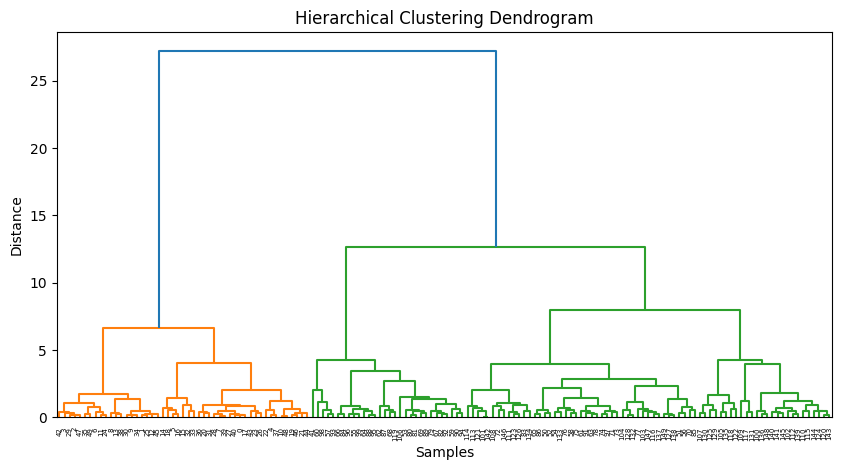

In [12]:
# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10,5))
linked = linkage(x_scaled, method='ward')

dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [13]:
# Visualization of Clusters
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Feature 2')

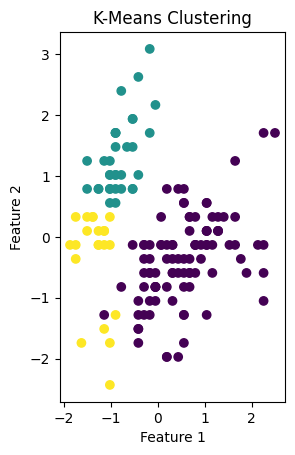

In [14]:
# KMeans Plot
plt.subplot(1,2,1)
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

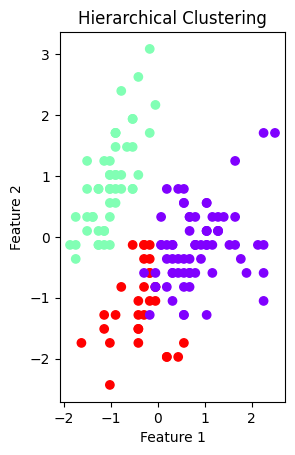

In [15]:
# Hierarchical Plot
plt.subplot(1,2,2)
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=hierarchical_labels, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()